# Systems Genetics 2026 – Final Project

Pipeline: QTL analysis (Section 2) → eQTL analysis (Section 3) → QTL/eQTL overlap (Section 4) → causality / mediation tests (Section 5).

All theoretical answers and discussion are in the report; this notebook contains code and results only.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f as f_dist

GENOTYPES_FILE = 'genotypes.xls'
PHENOTYPES_FILE = 'phenotypes.xls'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Chosen phenotypes (Section 1).
# 881  = dorsal striatum volume adjusted for shrinkage, age, sex, plane of section and BXD epoch (Rosen et al. 2009);
# 1231 = morphine-induced locomotion, 0-180 min total, females (Philip et al. 2010).
PHENOTYPE_IDS = [881, 1231]

# Genotype encoding for the additive linear-regression model (heterozygotes considered)
GENOTYPE_ENCODING = {'B': 0.0, 'H': 1.0, 'D': 2.0}   # 'U' (unknown) -> NaN
FDR_ALPHA = 0.05          # BH-FDR significance level on q-values
MIN_STRAINS_PER_SNP = 8   # skip SNPs with fewer informative strains
N_FALLBACK_SNPS = 15      # if no significant SNP: report the 15 lowest P-values

## Section 2 – QTL analysis

Parse the Excel files → per-SNP regression F-test (B=0, H=1, D=2) → BH-FDR → CSV of significant SNPs (or 15 lowest-P).

### Parsing

In [2]:
def load_genotypes(path=GENOTYPES_FILE):
    """Genotype table: one row per SNP with Locus / Chr / Position + one column per BXD strain (B/D/H/U)."""
    genotype_table = pd.read_excel(path, header=1)
    strain_columns = [c for c in genotype_table.columns if str(c).startswith('BXD')]
    # a handful of calls are lower-case in the file -> normalise
    genotype_table[strain_columns] = genotype_table[strain_columns].apply(lambda calls: calls.str.upper())
    genotype_table = genotype_table.rename(columns={'Chr_Build37': 'Chr', 'Build37_position': 'Position'})
    return genotype_table[['Locus', 'Chr', 'Position'] + strain_columns], strain_columns


def load_phenotypes(path=PHENOTYPES_FILE):
    """Phenotype table: one row per phenotype (ID_FOR_CHECK), one column per strain (strain means)."""
    return pd.read_excel(path)


def encode_genotypes(genotype_table, strain_columns):
    """Numeric SNP x strain matrix, B=0 / H=1 / D=2, NaN for unknown calls."""
    encoded = genotype_table[strain_columns].apply(lambda calls: calls.map(GENOTYPE_ENCODING))   # unmapped ('U') -> NaN
    return encoded.to_numpy(dtype=float)


def get_phenotype_vector(phenotype_table, phenotype_id, strain_columns):
    """Strain means of one phenotype, aligned to `strain_columns` (NaN where the strain was not measured)."""
    rows = phenotype_table.loc[phenotype_table['ID_FOR_CHECK'] == phenotype_id]
    if rows.empty:
        raise KeyError(f'phenotype {phenotype_id} not found')
    row = rows.iloc[0]
    values = pd.to_numeric(row.reindex(strain_columns), errors='coerce').to_numpy(dtype=float)
    return values, row['Phenotype']


genotypes, STRAINS = load_genotypes()
phenotypes = load_phenotypes()
STRAINS = [strain for strain in STRAINS if strain in phenotypes.columns]      # strains present in both files
GENOTYPE_MATRIX = encode_genotypes(genotypes, STRAINS)                        # SNPs x strains, 0/1/2/NaN

print(f'{len(genotypes)} SNPs x {len(STRAINS)} BXD strains; {len(phenotypes)} phenotypes')
print('unknown genotype calls:', f'{np.isnan(GENOTYPE_MATRIX).mean():.1%}')
genotypes.head(3)

3796 SNPs x 92 BXD strains; 2885 phenotypes
unknown genotype calls: 3.3%


,Locus,Chr,Position,BXD1,BXD2,BXD5,BXD6,BXD8,BXD9,BXD11,...,BXD94,BXD95,BXD96,BXD97,BXD98,BXD99,BXD100,BXD101,BXD102,BXD103
0,rs6269442,1,3482276,B,B,D,D,D,B,B,...,D,D,B,B,B,B,B,U,U,U
1,rs6365999,1,4811063,B,B,D,D,D,B,B,...,D,D,B,B,B,B,B,U,U,U
2,rs6376963,1,5008090,B,B,D,D,D,B,B,...,D,D,B,B,B,B,B,U,U,U


### Association test (F-test of the linear regression) and BH-FDR

In [3]:
def f_test_all_snps(genotype_matrix, trait, min_n=MIN_STRAINS_PER_SNP):
    """F-test of the simple linear regression trait ~ b0 + b1 * genotype, for every SNP at once.

    genotype_matrix : (n_snps, n_strains) numeric genotypes (0/1/2, NaN = unknown)
    trait           : (n_strains,) trait values (NaN = strain not measured)
    Returns (p_values, n_strains_used); NaN P-value for SNPs that are monomorphic in the measured strains
    or have fewer than `min_n` informative strains.
    F = (SS_regression / 1) / (SS_residual / (n - 2)),  F ~ F(1, n-2) under H0: b1 = 0.
    """
    measured = ~np.isnan(trait)
    genotype_matrix, trait = genotype_matrix[:, measured], trait[measured]
    known = ~np.isnan(genotype_matrix)
    x = np.where(known, genotype_matrix, 0.0)
    y = np.where(known, trait, 0.0)               # trait masked per SNP by its known genotypes
    n = known.sum(axis=1)
    sum_x, sum_y = x.sum(axis=1), y.sum(axis=1)
    sum_xx, sum_yy, sum_xy = (x * x).sum(axis=1), (y * y).sum(axis=1), (x * y).sum(axis=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ss_x = sum_xx - sum_x ** 2 / n            # centred sums of squares / cross-products
        ss_y = sum_yy - sum_y ** 2 / n
        ss_xy = sum_xy - sum_x * sum_y / n
        ss_regression = ss_xy ** 2 / ss_x
        ss_residual = ss_y - ss_regression
        f_statistic = ss_regression / (ss_residual / (n - 2))
        p_values = f_dist.sf(f_statistic, 1, n - 2)
    p_values[(n < min_n) | ~(ss_x > 0)] = np.nan
    return p_values, n


def bh_fdr(p_values):
    """Benjamini-Hochberg adjusted P-values (q-values). NaNs are ignored and returned as NaN."""
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full_like(p_values, np.nan)
    valid = ~np.isnan(p_values)
    valid_p = p_values[valid]
    n_tests = valid_p.size
    order = np.argsort(valid_p)
    adjusted = valid_p[order] * n_tests / np.arange(1, n_tests + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]   # enforce monotonicity
    valid_q = np.empty(n_tests)
    valid_q[order] = np.minimum(adjusted, 1.0)
    q_values[valid] = valid_q
    return q_values

### QTL pipeline

In [4]:
def run_qtl_pipeline(phenotype_id, alpha=FDR_ALPHA):
    """Full QTL scan for one phenotype. Returns a DataFrame (one row per SNP) sorted by P-value,
    and writes the significant SNPs (or the 15 lowest-P SNPs) to results/qtl_<id>.csv."""
    trait, trait_name = get_phenotype_vector(phenotypes, phenotype_id, STRAINS)
    p_values, n_strains = f_test_all_snps(GENOTYPE_MATRIX, trait)
    results = genotypes[['Locus', 'Chr', 'Position']].copy()
    results['n_strains'] = n_strains
    results['p_value'] = p_values
    results['q_value'] = bh_fdr(p_values)
    results['significant'] = results['q_value'] < alpha
    results = results.sort_values('p_value').reset_index(drop=True)

    n_significant = int(results['significant'].sum())
    reported = results[results['significant']] if n_significant > 0 else results.head(N_FALLBACK_SNPS)
    reported[['Locus', 'q_value']].rename(columns={'q_value': 'adjusted_p_value'}).to_csv(
        f'{RESULTS_DIR}/qtl_{phenotype_id}.csv', index=False)

    print(f'Phenotype {phenotype_id}: {trait_name.strip()}')
    print(f'  strains measured: {int((~np.isnan(trait)).sum())}  |  SNPs tested: {int(results.p_value.notna().sum())}')
    print(f'  significant SNPs (q < {alpha}): {n_significant}'
          + ('' if n_significant else f'  -> reporting {N_FALLBACK_SNPS} lowest P-values'))
    if n_significant:
        print('  significant SNPs per chromosome:', results[results.significant].groupby('Chr').size().to_dict())
    return results

### QTL scan of the two chosen phenotypes

In [5]:
qtl_results = {phenotype_id: run_qtl_pipeline(phenotype_id) for phenotype_id in PHENOTYPE_IDS}

Phenotype 881: Central nervous system, morphology: Striatum volume, dorsal striatum, bilateral and adjusted for shrinkage, age, sex, plane of section, and BXD group/epoch (mm^3)
  strains measured: 53  |  SNPs tested: 3796
  significant SNPs (q < 0.05): 24
  significant SNPs per chromosome: {6: 24}
Phenotype 1231: Morphine response (50 mg/kg ip), locomotion from 0-180 min (total activity over 3 hour test) after injection in an activity chamber for females [cm]
  strains measured: 64  |  SNPs tested: 3796
  significant SNPs (q < 0.05): 38
  significant SNPs per chromosome: {5: 7, 10: 25, 11: 6}


In [6]:
# Significant SNPs (or 15 lowest P) per phenotype - the content of results/qtl_<id>.csv
for phenotype_id, results in qtl_results.items():
    reported = results[results.significant] if results.significant.any() else results.head(N_FALLBACK_SNPS)
    print(f'\n=== Phenotype {phenotype_id}: {len(reported)} SNPs written to {RESULTS_DIR}/qtl_{phenotype_id}.csv ===')
    display(reported[['Locus', 'Chr', 'Position', 'n_strains', 'p_value', 'q_value']].reset_index(drop=True))


=== Phenotype 881: 24 SNPs written to results/qtl_881.csv ===


,Locus,Chr,Position,n_strains,p_value,q_value
0,rs13478889,6,91386029,53,0.000015,0.012110
1,rs3661039,6,90308024,53,0.000015,0.012110
2,rs13478880,6,88537081,53,0.000018,0.012110
3,rs3713705,6,88668211,53,0.000018,0.012110
4,rs4226061,6,86579760,53,0.000019,0.012110
5,rs13475374,6,86953033,53,0.000019,0.012110
6,rs13478871,6,85767550,53,0.000028,0.013520
7,CEL-6_86437630,6,86058923,53,0.000028,0.013520
8,gnf06.086.089,6,87099761,53,0.000036,0.013841
9,rs13478876,6,87384144,53,0.000036,0.013841



=== Phenotype 1231: 38 SNPs written to results/qtl_1231.csv ===


,Locus,Chr,Position,n_strains,p_value,q_value
0,rs13480484,10,8189404,64,0.000002,0.001804
1,rs4228079,10,4609418,64,0.000002,0.001804
2,rs3721803,10,3342586,64,0.000002,0.001804
3,rs3695003,10,7632997,64,0.000002,0.001804
4,D10Mit28,10,9133173,64,0.000003,0.002063
5,rs6185923,10,5378623,64,0.000003,0.002063
6,rs13481187,11,100513550,64,0.000023,0.011003
7,rs13481186,11,100224674,64,0.000023,0.011003
8,rs3664101,10,9329071,64,0.000094,0.025832
9,rs4139678,10,12004986,64,0.000094,0.025832


## Section 3 – eQTL analysis

### 3.1 Preprocessing of the expression data

Steps (a)–(h) of the assignment; thresholds for (d)/(e) are per-dataset percentiles (histograms below);
hypothalamus gene positions are lifted over from mm10 to mm9 (the build of the genotype file and the liver platform).

In [7]:
import urllib.request
import GEOparse
from pyliftover import LiftOver

GEO_DIR = 'data/geo'
TISSUES = {'hypothalamus': 'GSE36674', 'liver': 'GSE17522'}
MAX_QUANTILE = 0.10   # (d) drop probes whose maximal value is in the lowest 10% of the dataset
VAR_QUANTILE = 0.10   # (e) drop probes whose variance is in the lowest 10% of the remaining probes
CHAIN_URL = 'https://hgdownload.soe.ucsc.edu/goldenPath/mm10/liftOver/mm10ToMm9.over.chain.gz'
CHAIN_FILE = 'data/liftover/mm10ToMm9.over.chain.gz'
X_CHROMOSOME = 20     # chromosome number used for X in the genotype file


def download_geo(accession):
    """(a) Download (or load the cached copy of) a GEO series with its platform annotation."""
    os.makedirs(GEO_DIR, exist_ok=True)
    return GEOparse.get_GEO(accession, destdir=GEO_DIR, silent=True)


geo_series = {tissue: download_geo(accession) for tissue, accession in TISSUES.items()}
for tissue, series in geo_series.items():
    print(f"{tissue}: {TISSUES[tissue]} - {series.metadata['title'][0]} | platform {list(series.gpls)[0]} | {len(series.gsms)} arrays")

hypothalamus: GSE36674 - Expression data for mouse hypothalamus | platform GPL6246 | 89 arrays
liver: GSE17522 - BXD Mouse Liver Gene Expression | platform GPL6466 | 122 arrays


#### Parsing: expression matrix and platform annotation

In [8]:
def expression_matrix(series):
    """Probes x arrays matrix of the deposited normalised VALUEs, plus the strain of every array
    (taken from the 'strain: ...' field of the sample characteristics)."""
    values_per_array, strain_per_array = {}, {}
    for array_id, sample in series.gsms.items():
        characteristics = dict(entry.split(': ', 1) for entry in sample.metadata['characteristics_ch1'])
        strain_per_array[array_id] = characteristics['strain']
        values_per_array[array_id] = sample.table.set_index('ID_REF')['VALUE']
    expression = pd.DataFrame(values_per_array)
    expression.index = expression.index.astype(str)
    return expression, pd.Series(strain_per_array)


def chromosome_number(name):
    """'chr5' -> 5, 'chrX' -> 20 (as in the genotype file); NaN for unplaced contigs, Y and M."""
    name = str(name).replace('chr', '')
    if name == 'X':
        return X_CHROMOSOME
    return int(name) if name.isdigit() else np.nan


def annotate_gpl6246(platform_table):
    """Affymetrix MoGene 1.0 ST (hypothalamus). Only 'main' transcript clusters are genes (the rest are controls).
    Gene symbol = 2nd field of the primary gene_assignment entry ('RefSeq // Symbol // name // cytoband // Entrez /// ...').
    Position = transcript-cluster start (GRCm38)."""
    clusters = platform_table[platform_table['category'] == 'main'].set_index('ID')

    def primary_symbol(gene_assignment):
        if not isinstance(gene_assignment, str):
            return None
        fields = [field.strip() for field in gene_assignment.split('///')[0].split('//')]
        return fields[1] if len(fields) > 1 and fields[1] not in ('', '---') else None

    annotation = pd.DataFrame({'symbol': clusters['gene_assignment'].map(primary_symbol),
                               'chr': clusters['seqname'].map(chromosome_number),
                               'pos': pd.to_numeric(clusters['RANGE_START'], errors='coerce')})
    annotation.index = annotation.index.astype(str)
    return annotation


def annotate_gpl6466(platform_table):
    """Agilent G4121A (liver). Non-control probes only; GENE_SYMBOL column; position = probe location 'chrN:start-end' (mm9)."""
    probes = platform_table[platform_table['CONTROL_TYPE'] == 'FALSE'].set_index('ID')
    location = probes['CHROMOSOMAL_LOCATION'].str.extract(r'^(chr[0-9XY]+):(\d+)-')
    annotation = pd.DataFrame({'symbol': probes['GENE_SYMBOL'],
                               'chr': location[0].map(chromosome_number),
                               'pos': pd.to_numeric(location[1], errors='coerce')})
    annotation.index = annotation.index.astype(str)
    return annotation


def liftover_mm10_to_mm9(annotation):
    """Convert GRCm38 positions to NCBI Build 37 with the UCSC chain file. Positions that do not map
    (or map to another chromosome) become NaN."""
    os.makedirs(os.path.dirname(CHAIN_FILE), exist_ok=True)
    if not os.path.exists(CHAIN_FILE):
        urllib.request.urlretrieve(CHAIN_URL, CHAIN_FILE)
    lifter = LiftOver(CHAIN_FILE)

    def convert(chromosome, position):
        if np.isnan(chromosome) or np.isnan(position):
            return np.nan
        chromosome_name = 'chrX' if chromosome == X_CHROMOSOME else f'chr{int(chromosome)}'
        hits = lifter.convert_coordinate(chromosome_name, int(position))
        return hits[0][1] if hits and chromosome_number(hits[0][0]) == chromosome else np.nan

    lifted = annotation.copy()
    lifted['pos'] = [convert(chromosome, position) for chromosome, position in zip(annotation['chr'], annotation['pos'])]
    return lifted


ANNOTATORS = {'hypothalamus': annotate_gpl6246, 'liver': annotate_gpl6466}

#### Preprocessing steps (b)–(h)

In [9]:
def keep_genotyped_strains(expression, strain_per_array):
    """(b) Keep only arrays of BXD strains that are present in the genotype file."""
    genotyped_arrays = strain_per_array[strain_per_array.isin(STRAINS)]
    return expression[genotyped_arrays.index], genotyped_arrays


def drop_without_symbol(expression, annotation):
    """(c) Remove probes that have no gene identifier."""
    has_symbol = annotation.loc[expression.index, 'symbol'].notna()
    return expression[has_symbol]


def drop_low_max(expression, quantile):
    """(d) Remove probes whose maximal value is below the given quantile of the per-probe maxima."""
    max_per_probe = expression.max(axis=1)
    threshold = max_per_probe.quantile(quantile)
    return expression[max_per_probe >= threshold], max_per_probe, threshold


def drop_low_variance(expression, quantile):
    """(e) Remove probes whose variance is below the given quantile of the per-probe variances."""
    variance_per_probe = expression.var(axis=1)
    threshold = variance_per_probe.quantile(quantile)
    return expression[variance_per_probe >= threshold], variance_per_probe, threshold


def one_probe_per_gene(expression, annotation):
    """(f) Keep the highest-variance probe of every gene; rows are re-indexed by gene symbol."""
    symbol_per_probe = annotation.loc[expression.index, 'symbol']
    best_probe_per_gene = expression.var(axis=1).groupby(symbol_per_probe).idxmax()
    gene_expression = expression.loc[best_probe_per_gene.values].set_index(best_probe_per_gene.index)
    gene_annotation = annotation.loc[best_probe_per_gene.values].set_index(best_probe_per_gene.index)
    return gene_expression, gene_annotation


def average_per_strain(expression, strain_per_array):
    """(h) Average the arrays of the same strain -> genes x strains matrix of strain means."""
    return expression.T.groupby(strain_per_array).mean().T


def representative_snps(strains):
    """(g) Genotypes restricted to `strains` (genome order). Consecutive SNPs carrying identical genotypes across
    these strains (unknown calls 'U' included in the comparison) give identical association results; each such run is
    represented by its first SNP, and the run's end position (RunEnd) and size are recorded (the run starts at the SNP).
    Returns the SNP table, the encoded SNP x strain matrix, the strain order, and a Series mapping every SNP of the
    genotype file to its representative SNP."""
    strain_columns = [strain for strain in STRAINS if strain in set(strains)]
    ordered = genotypes.sort_values(['Chr', 'Position']).reset_index(drop=True)
    calls = ordered[strain_columns].fillna('U').to_numpy(dtype=str)
    same_chromosome = ordered['Chr'].to_numpy()[1:] == ordered['Chr'].to_numpy()[:-1]
    same_as_previous = (calls[1:] == calls[:-1]).all(axis=1) & same_chromosome
    is_representative = np.concatenate([[True], ~same_as_previous])
    run_id = np.cumsum(is_representative)
    runs = ordered.groupby(run_id)['Position'].agg(RunEnd='max', RunSize='size')
    snp_table = ordered.loc[is_representative, ['Locus', 'Chr', 'Position']].reset_index(drop=True)
    snp_table = pd.concat([snp_table, runs.reset_index(drop=True)], axis=1)
    representative_of = pd.Series(ordered['Locus'].where(is_representative).ffill().to_numpy(), index=ordered['Locus'])
    return snp_table, encode_genotypes(ordered.loc[is_representative], strain_columns), strain_columns, representative_of

hypothalamus: 34760 probes x 89 arrays; strains not in the genotype file (dropped): ['B6D2', 'BXD92A', 'C57BL/6J', 'D2B6F1', 'DBA/2J']
  thresholds: max value >= 6.104 (10% quantile), variance >= 0.0089 (10% quantile)


liver: 20868 probes x 122 arrays; strains not in the genotype file (dropped): ['B6D2F1', 'BXD11TY', 'C57BL6J', 'DBA2J']
  thresholds: max value >= -0.683 (10% quantile), variance >= 0.0210 (10% quantile)


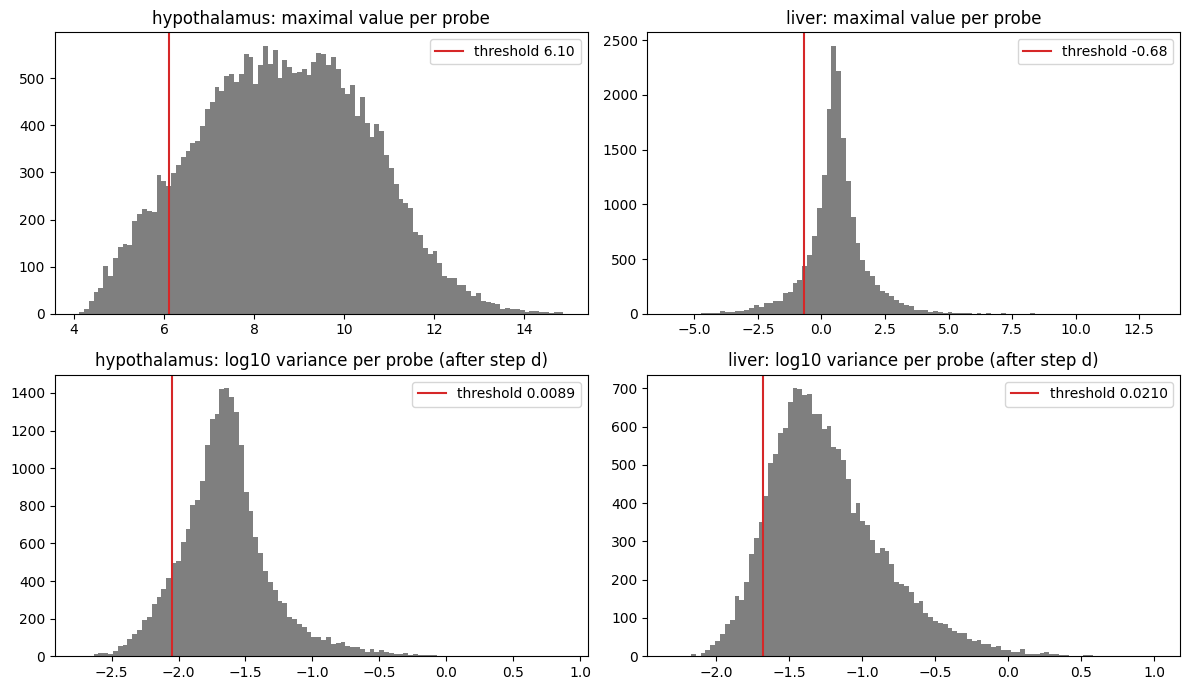

hypothalamus: 1598 representative SNPs; run size median 2 (max 12), run span median 0.38 Mb (max 10.0 Mb)
liver: 1403 representative SNPs; run size median 2 (max 14), run span median 0.47 Mb (max 10.3 Mb)


,hypothalamus,liver
annotated probes,28101,20868
(b) arrays of genotyped BXD strains,79,79
(c) probes with gene symbol,26710,19272
(d) probes with max >= threshold,24042,17348
(e) probes with variance >= threshold,21637,15613
(f) genes (one probe each),19577,14659
(f) genes with a genomic position,19453,14579
(h) strains after averaging,45,40
(g) representative SNPs,1598,1403


In [10]:
expression = {}          # tissue -> genes x strains matrix of strain means
gene_annotation = {}     # tissue -> symbol / chr / pos (mm9) per gene
snp_table = {}           # tissue -> representative SNPs (Locus, Chr, Position)
snp_matrix = {}          # tissue -> encoded representative SNPs x strains
representative_of = {}   # tissue -> every SNP of the genotype file -> its representative SNP
step_counts = {}         # tissue -> number of rows after each preprocessing step

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for column, tissue in enumerate(TISSUES):
    series = geo_series[tissue]
    probes, strain_per_array = expression_matrix(series)
    annotation = ANNOTATORS[tissue](series.gpls[list(series.gpls)[0]].table)
    if tissue == 'hypothalamus':
        annotation = liftover_mm10_to_mm9(annotation)
    print(f'{tissue}: {probes.shape[0]} probes x {probes.shape[1]} arrays; strains not in the genotype file (dropped): '
          f'{sorted(set(strain_per_array) - set(STRAINS))}')

    counts = {}
    probes = probes.loc[probes.index.intersection(annotation.index)]
    counts['annotated probes'] = len(probes)
    probes, strain_per_array = keep_genotyped_strains(probes, strain_per_array)
    counts['(b) arrays of genotyped BXD strains'] = probes.shape[1]
    probes = drop_without_symbol(probes, annotation)
    counts['(c) probes with gene symbol'] = len(probes)
    probes, max_per_probe, max_threshold = drop_low_max(probes, MAX_QUANTILE)
    counts['(d) probes with max >= threshold'] = len(probes)
    probes, variance_per_probe, variance_threshold = drop_low_variance(probes, VAR_QUANTILE)
    counts['(e) probes with variance >= threshold'] = len(probes)
    genes, gene_annotation[tissue] = one_probe_per_gene(probes, annotation)
    counts['(f) genes (one probe each)'] = len(genes)
    counts['(f) genes with a genomic position'] = int(gene_annotation[tissue]['pos'].notna().sum())
    strain_means = average_per_strain(genes, strain_per_array)
    counts['(h) strains after averaging'] = strain_means.shape[1]
    snp_table[tissue], snp_matrix[tissue], strain_order, representative_of[tissue] = representative_snps(strain_means.columns)
    counts['(g) representative SNPs'] = len(snp_table[tissue])
    expression[tissue] = strain_means[strain_order]
    step_counts[tissue] = counts
    print(f'  thresholds: max value >= {max_threshold:.3f} ({MAX_QUANTILE:.0%} quantile), '
          f'variance >= {variance_threshold:.4f} ({VAR_QUANTILE:.0%} quantile)')

    axes[0, column].hist(max_per_probe, bins=100, color='C7')
    axes[0, column].axvline(max_threshold, color='C3', label=f'threshold {max_threshold:.2f}')
    axes[0, column].set_title(f'{tissue}: maximal value per probe'); axes[0, column].legend()
    axes[1, column].hist(np.log10(variance_per_probe), bins=100, color='C7')
    axes[1, column].axvline(np.log10(variance_threshold), color='C3', label=f'threshold {variance_threshold:.4f}')
    axes[1, column].set_title(f'{tissue}: log10 variance per probe (after step d)'); axes[1, column].legend()
plt.tight_layout(); plt.show()

for tissue in TISSUES:
    runs = snp_table[tissue]
    print(f'{tissue}: {len(runs)} representative SNPs; run size median {runs.RunSize.median():.0f} (max {runs.RunSize.max()}), '
          f'run span median {(runs.RunEnd - runs.Position).median() / 1e6:.2f} Mb (max {(runs.RunEnd - runs.Position).max() / 1e6:.1f} Mb)')
pd.DataFrame(step_counts)

### 3.2 eQTL association test

Section 2's F-test for every gene × representative SNP; BH-FDR pooled per tissue; every pair with q < `FDR_ALPHA` is an eQTL.

In [11]:
def eqtl_scan(strain_means, snp_matrix, snp_loci):
    """F-test P-value of every gene x SNP pair. Returns a genes x SNPs DataFrame."""
    p_values = np.vstack([f_test_all_snps(snp_matrix, gene_values)[0] for gene_values in strain_means.to_numpy()])
    return pd.DataFrame(p_values, index=strain_means.index, columns=snp_loci)


def select_eqtls(p_values, q_values, snp_table, annotation, alpha=FDR_ALPHA):
    """One row per significant (SNP, gene) pair (q < alpha), with the gene's position, the SNP's position and
    the end of its run of identical SNPs, P and q."""
    gene_index, snp_index = np.nonzero(q_values.to_numpy() < alpha)
    genes = p_values.index[gene_index]
    gene_info = pd.DataFrame({'gene': genes,
                              'gene_chr': annotation.loc[genes, 'chr'].to_numpy(),
                              'gene_pos': annotation.loc[genes, 'pos'].to_numpy()})
    snp_info = (snp_table.iloc[snp_index, :][['Locus', 'Chr', 'Position', 'RunEnd']].reset_index(drop=True)
                .rename(columns={'Locus': 'snp', 'Chr': 'snp_chr', 'Position': 'snp_pos', 'RunEnd': 'run_end'}))
    eqtls = pd.concat([gene_info, snp_info], axis=1)
    eqtls['p_value'] = p_values.to_numpy()[gene_index, snp_index]
    eqtls['q_value'] = q_values.to_numpy()[gene_index, snp_index]
    return eqtls.sort_values('p_value').reset_index(drop=True)


eqtl_p_values, eqtl_q_values, eqtls = {}, {}, {}
for tissue in TISSUES:
    p_values = eqtl_scan(expression[tissue], snp_matrix[tissue], snp_table[tissue]['Locus'])
    q_values = pd.DataFrame(bh_fdr(p_values.to_numpy().ravel()).reshape(p_values.shape),
                            index=p_values.index, columns=p_values.columns)
    eqtl_p_values[tissue], eqtl_q_values[tissue] = p_values, q_values
    eqtls[tissue] = select_eqtls(p_values, q_values, snp_table[tissue], gene_annotation[tissue])
    eqtls[tissue].to_csv(f'{RESULTS_DIR}/eqtl_{tissue}.csv', index=False)
    n_tests = int(p_values.notna().sum().sum())
    print(f'{tissue}: {p_values.shape[0]} genes x {p_values.shape[1]} SNPs = {n_tests:,} tests | '
          f'eQTLs (SNP-gene pairs with q < {FDR_ALPHA}): {len(eqtls[tissue]):,} | '
          f'genes with >= 1 eQTL: {eqtls[tissue].gene.nunique():,} | distinct eQTL SNPs: {eqtls[tissue].snp.nunique():,} | '
          f'SNPs per gene: median {eqtls[tissue].groupby("gene").size().median():.0f}, max {eqtls[tissue].groupby("gene").size().max()}')

eqtls['hypothalamus'].head(10)

hypothalamus: 19577 genes x 1598 SNPs = 31,284,046 tests | eQTLs (SNP-gene pairs with q < 0.05): 7,509 | genes with >= 1 eQTL: 1,416 | distinct eQTL SNPs: 1,317 | SNPs per gene: median 4, max 23


liver: 14659 genes x 1403 SNPs = 20,566,577 tests | eQTLs (SNP-gene pairs with q < 0.05): 6,804 | genes with >= 1 eQTL: 1,285 | distinct eQTL SNPs: 1,209 | SNPs per gene: median 4, max 20


,gene,gene_chr,gene_pos,snp,snp_chr,snp_pos,run_end,p_value,q_value
0,Hspa8,9.0,40609356.0,rs6240566,9,40268402,40515147,3.201308e-30,5.455211e-23
1,Gm22289,7.0,67049641.0,rs13479276,7,65717523,66413236,3.487536e-30,5.455211e-23
2,Rpl3,15.0,79908225.0,rs3667755,15,78741347,81745213,6.264050e-30,6.532161e-23
3,Hdhd3,4.0,62160046.0,rs13477735,4,61518987,61518987,6.761728e-29,5.288355e-22
4,Gm26337,7.0,66678425.0,rs13479276,7,65717523,66413236,4.551343e-27,2.847688e-20
5,Pttg1,11.0,43233764.0,D11Mit20,11,44552713,46029522,1.120278e-26,5.841137e-20
6,Dlg4,11.0,69830717.0,rs13481087,11,69415411,70265537,2.933592e-26,1.311066e-19
7,Alad,4.0,62170202.0,rs13477735,4,61518987,61518987,4.309699e-26,1.685310e-19
8,Aldh7a1,18.0,56685390.0,CEL-18_56957668,18,56618687,56763124,1.468643e-25,4.259439e-19
9,Sat2,11.0,69435554.0,rs13481087,11,69415411,70265537,1.478025e-25,4.259439e-19


### 3.3 Results analysis

cis = gene within `CIS_WINDOW` of the SNP's run (same chromosome); hotspot = trans-gene count above the uniform (Poisson)
expectation at P < `HOTSPOT_P`.

In [12]:
from scipy.stats import poisson

CIS_WINDOW = 2_000_000       # bp; SNP-gene distance for a cis-acting eQTL
HOTSPOT_P = 0.001            # Poisson tail probability defining a trans hotspot
HOTSPOT_MERGE_GAP = 5_000_000  # bp; hotspot SNPs closer than this are reported as one hotspot region


def classify_cis_trans(eqtl_pairs):
    """Add 'distance_bp' (gene to the SNP's run [snp_pos, run_end], same chromosome only) and 'type'
    (cis / trans / unknown) to the eQTL table."""
    distance = np.maximum(0, np.maximum(eqtl_pairs['snp_pos'] - eqtl_pairs['gene_pos'],
                                        eqtl_pairs['gene_pos'] - eqtl_pairs['run_end']))
    same_chromosome = eqtl_pairs['snp_chr'] == eqtl_pairs['gene_chr']
    eqtl_type = np.where(eqtl_pairs['gene_pos'].isna(), 'unknown',
                         np.where(same_chromosome & (distance <= CIS_WINDOW), 'cis', 'trans'))
    return eqtl_pairs.assign(distance_bp=np.where(same_chromosome, distance, np.nan), type=eqtl_type)


def genome_layout(tissue):
    """Cumulative offset of every chromosome (for genome-wide x axes) from the SNP and gene positions of a tissue."""
    chromosome_length = pd.concat([snp_table[tissue].groupby('Chr')['Position'].max(),
                                   gene_annotation[tissue].groupby('chr')['pos'].max()]).groupby(level=0).max()
    offsets = chromosome_length.cumsum().shift(fill_value=0)
    return offsets, chromosome_length


def genome_coordinate(chromosome, position, offsets):
    return offsets.reindex(chromosome).to_numpy() + position.to_numpy()


def chromosome_ticks(axis, offsets, chromosome_length, which='x'):
    """Chromosome names at the centre of each chromosome on the x or y axis."""
    centers = offsets + chromosome_length / 2
    labels = ['X' if chromosome == X_CHROMOSOME else str(int(chromosome)) for chromosome in offsets.index]
    if which == 'x':
        axis.set_xticks(centers)
        axis.set_xticklabels(labels)
    else:
        axis.set_yticks(centers)
        axis.set_yticklabels(labels)
    axis.tick_params(axis=which, length=0)


def shade_chromosomes(axis, offsets, chromosome_length):
    """Light background shading of every second chromosome along the x axis."""
    for index, (chromosome, start) in enumerate(offsets.items()):
        if index % 2:
            axis.axvspan(start, start + chromosome_length[chromosome], color='0.93', zorder=0)


def genes_per_snp(eqtl_pairs, tissue, eqtl_type=None):
    """Number of associated genes per representative SNP (all SNPs, zeros included), optionally for one eQTL type."""
    pairs = eqtl_pairs if eqtl_type is None else eqtl_pairs[eqtl_pairs['type'] == eqtl_type]
    return pairs.groupby('snp')['gene'].nunique().reindex(snp_table[tissue]['Locus'], fill_value=0)


def hotspot_threshold(trans_counts):
    """Smallest count that a SNP would exceed with probability < HOTSPOT_P if trans eQTLs were spread uniformly."""
    return poisson.isf(HOTSPOT_P, trans_counts.mean())


def hotspot_regions(hotspot_snps, max_gap=HOTSPOT_MERGE_GAP):
    """Merge hotspot SNPs on the same chromosome that lie within `max_gap` of each other into one region.
    Returns one row per region: span, number of SNPs, maximal number of trans genes and the SNP carrying it."""
    ordered = hotspot_snps.sort_values(['Chr', 'Position'])
    new_region = (ordered['Chr'] != ordered['Chr'].shift()) | (ordered['Position'].diff() > max_gap)
    region_id = new_region.cumsum()
    regions = ordered.groupby(region_id).agg(
        chr=('Chr', 'first'), start=('Position', 'min'), end=('Position', 'max'), n_snps=('Locus', 'size'),
        max_trans_genes=('trans_genes', 'max'))
    peak_index = ordered.groupby(region_id)['trans_genes'].idxmax()
    regions['peak_snp'] = ordered.loc[peak_index, 'Locus'].to_numpy()
    return regions.sort_values('max_trans_genes', ascending=False).reset_index(drop=True)


for tissue in TISSUES:
    eqtls[tissue] = classify_cis_trans(eqtls[tissue])
    eqtls[tissue].to_csv(f'{RESULTS_DIR}/eqtl_{tissue}.csv', index=False)

#### (a) Number of eQTLs, cis vs trans

In [13]:
def eqtl_counts(eqtl_pairs):
    by_type = eqtl_pairs['type'].value_counts()
    snp_types = eqtl_pairs.groupby('snp')['type'].agg(set)
    gene_types = eqtl_pairs.groupby('gene')['type'].agg(set)
    return pd.Series({
        'eQTLs (SNP-gene pairs)': len(eqtl_pairs),
        '  cis': by_type.get('cis', 0),
        '  trans': by_type.get('trans', 0),
        '  unknown (gene without position)': by_type.get('unknown', 0),
        'distinct eQTL SNPs': len(snp_types),
        '  cis only': int(sum(types == {'cis'} for types in snp_types)),
        '  trans only': int(sum(types == {'trans'} for types in snp_types)),
        '  both cis and trans': int(sum({'cis', 'trans'} <= types for types in snp_types)),
        'genes with an eQTL': len(gene_types),
        '  with a cis eQTL': int(sum('cis' in types for types in gene_types)),
        '  with a trans eQTL': int(sum('trans' in types for types in gene_types)),
    })


pd.DataFrame({tissue: eqtl_counts(eqtls[tissue]) for tissue in TISSUES})

,hypothalamus,liver
eQTLs (SNP-gene pairs),7509,6804
cis,3066,2320
trans,4434,4451
unknown (gene without position),9,33
distinct eQTL SNPs,1317,1209
cis only,245,184
trans only,388,364
both cis and trans,681,652
genes with an eQTL,1416,1285
with a cis eQTL,1128,872


#### (b) Distribution of the number of genes per eQTL

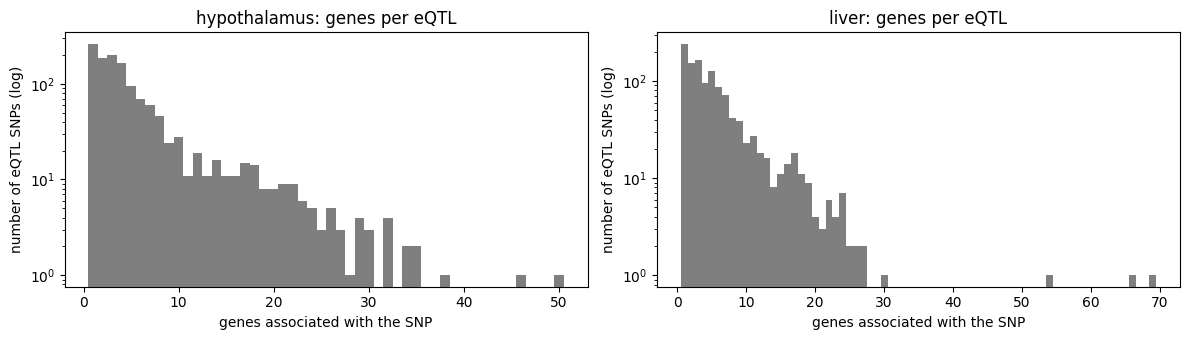

,hypothalamus,liver
count,1317.000,1209.000
mean,5.700,5.630
std,6.230,5.800
min,1.000,1.000
25%,2.000,2.000
50%,4.000,4.000
75%,7.000,7.000
max,50.000,69.000
SNPs with 0 genes,281.000,194.000
fraction with 1 gene,0.198,0.199


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
distribution_summary = {}
for axis, tissue in zip(axes, TISSUES):
    counts = genes_per_snp(eqtls[tissue], tissue)
    with_genes = counts[counts > 0]
    summary = with_genes.describe().round(2)
    summary['SNPs with 0 genes'] = int((counts == 0).sum())
    summary['fraction with 1 gene'] = round((with_genes == 1).mean(), 3)
    summary['fraction with <= 3 genes'] = round((with_genes <= 3).mean(), 3)
    summary['fraction with > 10 genes'] = round((with_genes > 10).mean(), 3)
    distribution_summary[tissue] = summary
    axis.hist(with_genes, bins=np.arange(0.5, with_genes.max() + 1.5), color='C7', log=True)
    axis.set_xlabel('genes associated with the SNP'); axis.set_ylabel('number of eQTL SNPs (log)')
    axis.set_title(f'{tissue}: genes per eQTL')
plt.tight_layout(); plt.show()
pd.DataFrame(distribution_summary)

#### (c) Number of genes per eQTL along the genome

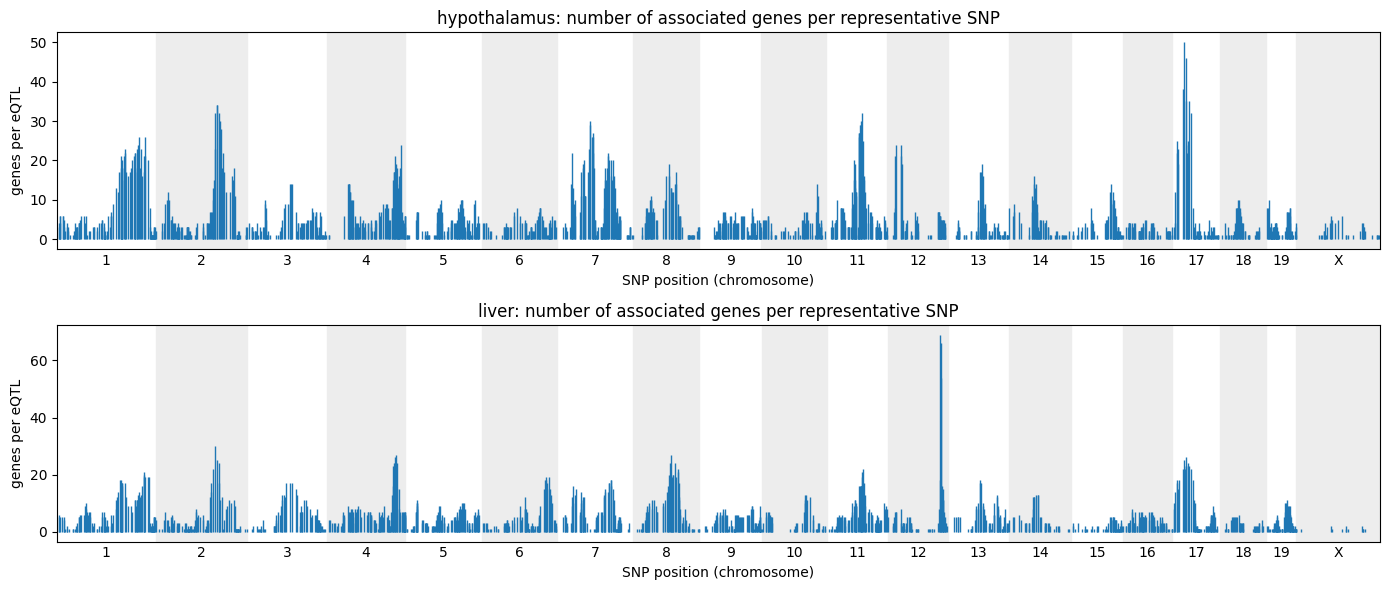

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
for axis, tissue in zip(axes, TISSUES):
    offsets, chromosome_length = genome_layout(tissue)
    counts = genes_per_snp(eqtls[tissue], tissue)
    x = genome_coordinate(snp_table[tissue]['Chr'], snp_table[tissue]['Position'], offsets)
    axis.vlines(x, 0, counts.to_numpy(), color='C0', linewidth=1)
    shade_chromosomes(axis, offsets, chromosome_length)
    chromosome_ticks(axis, offsets, chromosome_length)
    axis.set_xlim(0, offsets.iloc[-1] + chromosome_length.iloc[-1])
    axis.set_xlabel('SNP position (chromosome)'); axis.set_ylabel('genes per eQTL')
    axis.set_title(f'{tissue}: number of associated genes per representative SNP')
plt.tight_layout(); plt.show()

#### (d) P-value distributions of cis- and trans-associated genes

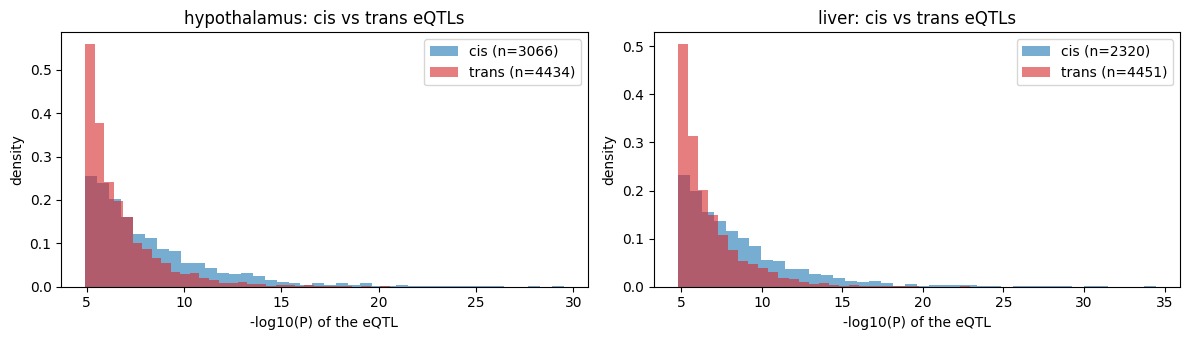

hypothalamus             liver         
               cis    trans      cis    trans
count      3066.00  4434.00  2320.00  4451.00
mean          8.30     6.76     8.46     6.72
std           3.43     2.11     3.55     2.17
min           4.92     4.92     4.78     4.78
25%           5.92     5.36     5.92     5.24
50%           7.21     6.05     7.45     5.99
75%           9.53     7.35     9.87     7.44
max          29.49    24.49    34.47    29.79

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
p_value_summary = {}
for axis, tissue in zip(axes, TISSUES):
    pairs = eqtls[tissue]
    for eqtl_type, color in [('cis', 'C0'), ('trans', 'C3')]:
        minus_log_p = -np.log10(pairs.loc[pairs['type'] == eqtl_type, 'p_value'])
        axis.hist(minus_log_p, bins=40, density=True, alpha=0.6, color=color, label=f'{eqtl_type} (n={len(minus_log_p)})')
        p_value_summary[(tissue, eqtl_type)] = minus_log_p.describe().round(2)
    axis.set_xlabel('-log10(P) of the eQTL'); axis.set_ylabel('density'); axis.set_title(f'{tissue}: cis vs trans eQTLs')
    axis.legend()
plt.tight_layout(); plt.show()
pd.DataFrame(p_value_summary)

#### (e) eQTL map: SNP position vs gene position, trans hotspots

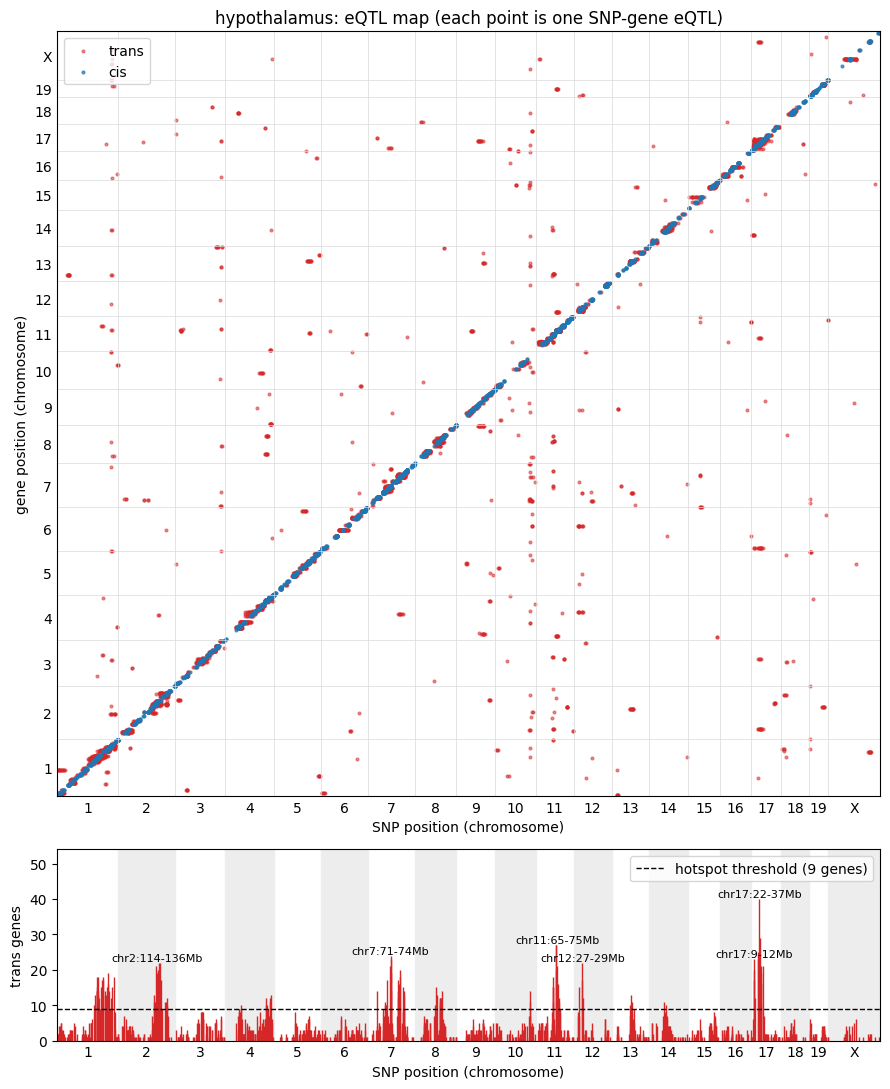

hypothalamus: 118 hotspot SNPs (> 9 trans genes; mean 2.77 per SNP) in 29 regions


,chr,start,end,n_snps,max_trans_genes,peak_snp
0,17,21827381,37015393,10,40,rs13482930
1,11,64515287,75282894,8,27,rs3695202
2,7,70840460,73604599,5,24,D7Mit199
3,17,8688392,11606730,4,23,gnf17.005.541
4,12,26992470,28507708,3,22,rs4229294
5,2,114022898,135953692,12,22,rs8264884
6,7,95155270,103251219,8,20,rs13479416
7,1,154395967,168323143,8,19,rs13476208
8,1,117626780,135115364,12,18,D1Mit91
9,1,182213911,182213911,1,18,rs13476267


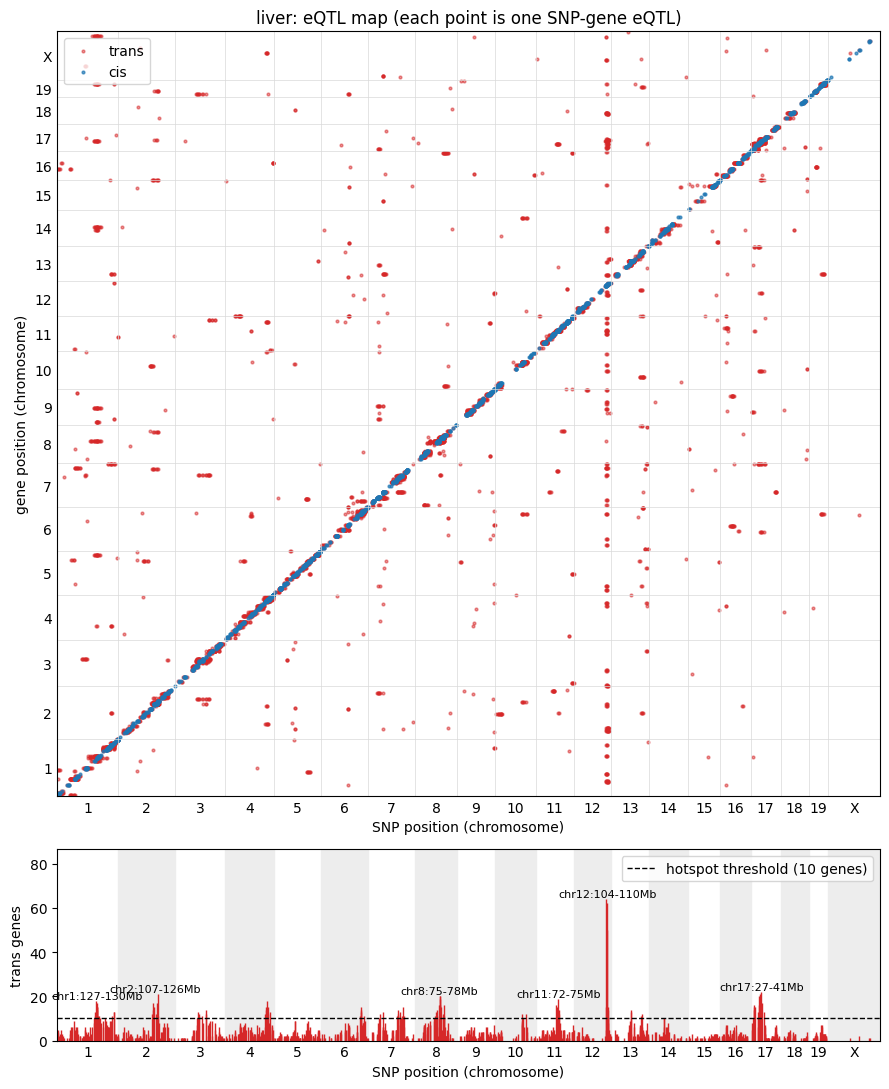

liver: 93 hotspot SNPs (> 10 trans genes; mean 3.17 per SNP) in 30 regions


,chr,start,end,n_snps,max_trans_genes,peak_snp
0,12,103658502,109609891,6,64,rs13481620
1,17,26950947,40708059,7,22,rs13482947
2,2,107081147,125704535,8,21,rs6374387
3,8,74935354,78352527,6,20,rs3696502
4,11,72486318,75282894,3,19,rs6217738
5,1,126516498,130485641,7,18,rs6189020
6,4,129249415,142772319,8,18,rs13478001
7,17,8688392,12508088,4,16,rs13482864
8,11,64515287,67192419,2,16,rs3695202
9,8,88546532,91144187,4,16,rs13479891


In [17]:
hotspots = {}
for tissue in TISSUES:
    offsets, chromosome_length = genome_layout(tissue)
    pairs = eqtls[tissue][eqtls[tissue]['type'] != 'unknown']
    snp_x = genome_coordinate(pairs['snp_chr'], pairs['snp_pos'], offsets)
    gene_y = genome_coordinate(pairs['gene_chr'], pairs['gene_pos'], offsets)
    trans_counts = genes_per_snp(eqtls[tissue], tissue, 'trans')
    threshold = hotspot_threshold(trans_counts)
    hotspot_snps = snp_table[tissue].assign(trans_genes=trans_counts.to_numpy())
    hotspots[tissue] = hotspot_snps[hotspot_snps['trans_genes'] > threshold].sort_values('trans_genes', ascending=False)

    fig, (map_axis, count_axis) = plt.subplots(2, 1, figsize=(9, 11), sharex=True,
                                               gridspec_kw={'height_ratios': [4, 1]})
    is_cis = (pairs['type'] == 'cis').to_numpy()
    map_axis.scatter(snp_x[~is_cis], gene_y[~is_cis], s=4, color='C3', alpha=0.5, label='trans')
    map_axis.scatter(snp_x[is_cis], gene_y[is_cis], s=4, color='C0', alpha=0.7, label='cis')
    for boundary in offsets.to_numpy()[1:]:
        map_axis.axvline(boundary, color='0.85', linewidth=0.5); map_axis.axhline(boundary, color='0.85', linewidth=0.5)
    genome_end = offsets.iloc[-1] + chromosome_length.iloc[-1]
    map_axis.set_xlim(0, genome_end); map_axis.set_ylim(0, genome_end)
    chromosome_ticks(map_axis, offsets, chromosome_length, which='x')
    chromosome_ticks(map_axis, offsets, chromosome_length, which='y')
    map_axis.tick_params(axis='x', labelbottom=True)           # keep the x tick labels despite sharex
    map_axis.set_xlabel('SNP position (chromosome)'); map_axis.set_ylabel('gene position (chromosome)')
    map_axis.set_title(f'{tissue}: eQTL map (each point is one SNP-gene eQTL)'); map_axis.legend(loc='upper left')

    all_x = genome_coordinate(snp_table[tissue]['Chr'], snp_table[tissue]['Position'], offsets)
    shade_chromosomes(count_axis, offsets, chromosome_length)
    count_axis.vlines(all_x, 0, trans_counts.to_numpy(), color='C3', linewidth=1)
    count_axis.axhline(threshold, color='k', linestyle='--', linewidth=1, label=f'hotspot threshold ({threshold:.0f} genes)')
    regions = hotspot_regions(hotspots[tissue])
    for _, region in regions.head(6).iterrows():
        chromosome_name = 'X' if region.chr == X_CHROMOSOME else int(region.chr)
        count_axis.annotate(f'chr{chromosome_name}:{region.start / 1e6:.0f}-{region.end / 1e6:.0f}Mb',
                            (offsets[region.chr] + (region.start + region.end) / 2, region.max_trans_genes),
                            fontsize=8, ha='center', va='bottom')
    chromosome_ticks(count_axis, offsets, chromosome_length)
    count_axis.set_ylim(0, trans_counts.max() * 1.35)   # headroom for the region labels
    count_axis.set_xlabel('SNP position (chromosome)'); count_axis.set_ylabel('trans genes'); count_axis.legend(loc='upper right')
    plt.tight_layout(); plt.show()

    print(f'{tissue}: {len(hotspots[tissue])} hotspot SNPs (> {threshold:.0f} trans genes; mean {trans_counts.mean():.2f} per SNP) '
          f'in {len(regions)} regions')
    display(regions.head(10))

## Section 4 – Combining QTL and eQTL results

Sets are compared over all 3,796 SNPs; a SNP is an eQTL SNP of a tissue if its representative SNP there has an eQTL.

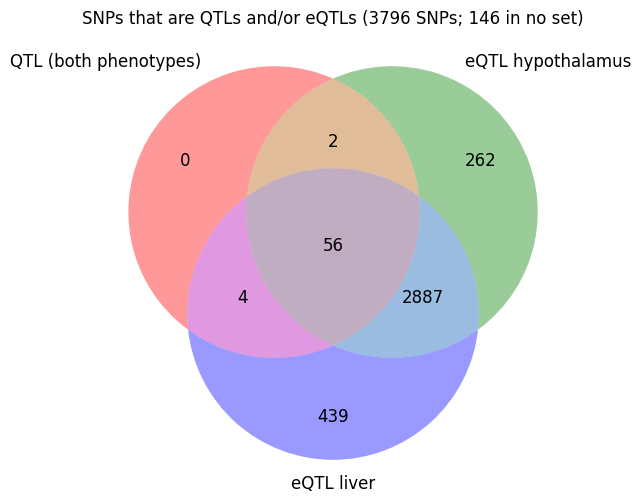

SNPs in each combination of sets:


,QTL,eQTL hypothalamus,eQTL liver,SNPs
0,False,True,True,2887
1,False,False,True,439
2,False,True,False,262
3,False,False,False,146
4,True,True,True,56
5,True,False,True,4
6,True,True,False,2


In [18]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm

qtl_snps = {phenotype_id: set(results.loc[results['significant'], 'Locus']) for phenotype_id, results in qtl_results.items()}
eqtl_snps = {tissue: set(eqtls[tissue]['snp']) for tissue in TISSUES}

snp_membership = pd.DataFrame({'QTL': genotypes['Locus'].isin(set().union(*qtl_snps.values())).to_numpy()},
                              index=genotypes['Locus'])
for tissue in TISSUES:
    snp_membership[f'eQTL {tissue}'] = representative_of[tissue].reindex(snp_membership.index).isin(eqtl_snps[tissue]).to_numpy()

membership_sets = [set(snp_membership.index[snp_membership[column]]) for column in snp_membership.columns]
n_in_no_set = int((~snp_membership).all(axis=1).sum())
fig, axis = plt.subplots(figsize=(7, 6))
venn = venn3(membership_sets, set_labels=('QTL (both phenotypes)', 'eQTL hypothalamus', 'eQTL liver'), ax=axis,
             layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1,) * 7))   # equal-sized regions -> legible counts
for label in venn.subset_labels:
    if label is not None:
        label.set_fontsize(12)
axis.set_title(f'SNPs that are QTLs and/or eQTLs ({len(snp_membership)} SNPs; {n_in_no_set} in no set)')
plt.show()

print('SNPs in each combination of sets:')
display(snp_membership.value_counts().rename('SNPs').reset_index())

In [19]:
# QTL SNPs of each phenotype: are they eQTL SNPs, and for which genes?
qtl_eqtl_pairs = {}     # (phenotype_id, tissue) -> eQTL pairs whose SNP represents a QTL SNP of the phenotype
for phenotype_id in PHENOTYPE_IDS:
    qtl_rows = snp_membership.loc[sorted(qtl_snps[phenotype_id])]
    print(f'Phenotype {phenotype_id}: {len(qtl_rows)} QTL SNPs | eQTL in hypothalamus: {int(qtl_rows["eQTL hypothalamus"].sum())} | '
          f'eQTL in liver: {int(qtl_rows["eQTL liver"].sum())} | both: {int((qtl_rows["eQTL hypothalamus"] & qtl_rows["eQTL liver"]).sum())} | '
          f'neither: {int((~qtl_rows["eQTL hypothalamus"] & ~qtl_rows["eQTL liver"]).sum())}')
    for tissue in TISSUES:
        representatives = set(representative_of[tissue].reindex(qtl_snps[phenotype_id]))
        pairs = eqtls[tissue][eqtls[tissue]['snp'].isin(representatives)]
        qtl_eqtl_pairs[(phenotype_id, tissue)] = pairs
        print(f'    {tissue}: {len(pairs)} eQTLs at the QTL SNPs -> {pairs["gene"].nunique()} genes '
              f'({pairs["type"].value_counts().to_dict()})')

# genes with a cis eQTL at the QTL loci (the natural candidates for Section 5)
for (phenotype_id, tissue), pairs in qtl_eqtl_pairs.items():
    cis_genes = pairs[pairs['type'] == 'cis'].sort_values('p_value').drop_duplicates('gene')
    print(f'\nPhenotype {phenotype_id}, {tissue}: cis genes at the QTL - '
          + (', '.join(f'{row.gene} (chr{int(row.gene_chr)}:{row.gene_pos / 1e6:.1f}Mb, q={row.q_value:.1e})' for row in cis_genes.itertuples())
             if len(cis_genes) else 'none'))

Phenotype 881: 24 QTL SNPs | eQTL in hypothalamus: 22 | eQTL in liver: 22 | both: 20 | neither: 0
    hypothalamus: 34 eQTLs at the QTL SNPs -> 11 genes ({'trans': 20, 'cis': 14})
    liver: 62 eQTLs at the QTL SNPs -> 20 genes ({'trans': 49, 'cis': 13})
Phenotype 1231: 38 QTL SNPs | eQTL in hypothalamus: 36 | eQTL in liver: 38 | both: 36 | neither: 0
    hypothalamus: 61 eQTLs at the QTL SNPs -> 18 genes ({'trans': 35, 'cis': 26})
    liver: 77 eQTLs at the QTL SNPs -> 21 genes ({'cis': 39, 'trans': 38})

Phenotype 881, hypothalamus: cis genes at the QTL - Nfu1 (chr6:87.0Mb, q=4.3e-06), Nup210 (chr6:91.0Mb, q=7.7e-05), Tpra1 (chr6:88.9Mb, q=4.3e-03), Chchd6 (chr6:89.3Mb, q=1.4e-02), Tgfa (chr6:86.1Mb, q=4.3e-02), Anxa4 (chr6:86.7Mb, q=4.9e-02)

Phenotype 881, liver: cis genes at the QTL - Anxa4 (chr6:86.7Mb, q=2.0e-11), Pcyox1 (chr6:86.3Mb, q=1.4e-03), V1rb3 (chr6:90.2Mb, q=1.6e-03), Cml5 (chr6:85.8Mb, q=2.4e-03), Aak1 (chr6:87.0Mb, q=1.5e-02)

Phenotype 1231, hypothalamus: cis genes 

## Section 5 – Causality analysis

### 5.1 Mediation test

M1: L→R→C, M2: L→C→R, M3: L→R and L→C (lecture models); Gaussian conditionals fitted by MLE, compared with AIC.
Triplets: (gene, phenotype) pairs whose eQTL SNP run lies within `NEARBY_WINDOW` of a QTL SNP of the phenotype.

In [20]:
NEARBY_WINDOW = 2_000_000    # bp; an eQTL SNP (run) within this distance of a QTL SNP is "nearby"
MIN_GENOTYPE_GROUP = 3       # strains in a genotype group needed to estimate its variance; smaller groups are dropped


def gaussian_log_likelihood(values, means, variance):
    """Sum of log N(value | mean, variance) over the observations."""
    return float(np.sum(-0.5 * np.log(2 * np.pi * variance) - (values - means) ** 2 / (2 * variance)))


def fit_genotype(genotype):
    """P(L): empirical frequency of each genotype group. Returns (log-likelihood, number of free parameters)."""
    groups, counts = np.unique(genotype, return_counts=True)
    frequencies = counts / counts.sum()
    return float(np.sum(counts * np.log(frequencies))), len(groups) - 1


def fit_given_genotype(values, genotype):
    """Y | L ~ N(mu_L, sigma^2_L): a mean and a variance per genotype group (MLE), as in the lecture.
    Returns (log-likelihood, number of parameters)."""
    log_likelihood, n_parameters = 0.0, 0
    for group in np.unique(genotype):
        group_values = values[genotype == group]
        variance = np.mean((group_values - group_values.mean()) ** 2)
        log_likelihood += gaussian_log_likelihood(group_values, group_values.mean(), variance)
        n_parameters += 2
    return log_likelihood, n_parameters


def drop_small_genotype_groups(genotype, expression_values, phenotype_values, min_group=MIN_GENOTYPE_GROUP):
    """Remove strains whose genotype group has fewer than `min_group` strains (its variance cannot be estimated)."""
    groups, counts = np.unique(genotype, return_counts=True)
    keep = np.isin(genotype, groups[counts >= min_group])
    return genotype[keep], expression_values[keep], phenotype_values[keep]


def fit_given_continuous(values, predictor):
    """Y | X ~ N(a X + b, sigma^2): least-squares (= MLE) regression line and MLE variance.
    Returns (log-likelihood, number of parameters)."""
    slope, intercept = np.polyfit(predictor, values, 1)
    fitted_means = slope * predictor + intercept
    variance = np.mean((values - fitted_means) ** 2)
    return gaussian_log_likelihood(values, fitted_means, variance), 3


def mediation_test(genotype, expression_values, phenotype_values):
    """Log-likelihood, number of parameters and AIC of M1 (L->R->C), M2 (L->C->R), M3 (L->R, L->C)."""
    ll_L, k_L = fit_genotype(genotype)
    ll_R_given_L, k_R_given_L = fit_given_genotype(expression_values, genotype)
    ll_C_given_L, k_C_given_L = fit_given_genotype(phenotype_values, genotype)
    ll_C_given_R, k_C_given_R = fit_given_continuous(phenotype_values, expression_values)
    ll_R_given_C, k_R_given_C = fit_given_continuous(expression_values, phenotype_values)
    models = {
        'M1 (L->R->C)': (ll_L + ll_R_given_L + ll_C_given_R, k_L + k_R_given_L + k_C_given_R),
        'M2 (L->C->R)': (ll_L + ll_C_given_L + ll_R_given_C, k_L + k_C_given_L + k_R_given_C),
        'M3 (L->R, L->C)': (ll_L + ll_R_given_L + ll_C_given_L, k_L + k_R_given_L + k_C_given_L),
    }
    return {name: {'log_likelihood': ll, 'n_parameters': k, 'AIC': 2 * k - 2 * ll} for name, (ll, k) in models.items()}

#### Triplets: genes whose eQTL is at or near a QTL

In [21]:
def collect_triplets(phenotype_id, tissue, window=NEARBY_WINDOW):
    """(gene, SNP) pairs of a tissue whose eQTL SNP run lies within `window` of a QTL SNP of the phenotype.
    One SNP per gene: the one with the strongest eQTL."""
    qtl = qtl_results[phenotype_id]
    qtl_positions = qtl.loc[qtl['significant'], ['Chr', 'Position']]
    pairs = eqtls[tissue]
    nearby = np.zeros(len(pairs), dtype=bool)
    for chromosome, position in qtl_positions.itertuples(index=False):
        distance = np.maximum(0, np.maximum(pairs['snp_pos'] - position, position - pairs['run_end']))
        nearby |= ((pairs['snp_chr'] == chromosome) & (distance <= window)).to_numpy()
    triplets = pairs[nearby].sort_values('p_value').drop_duplicates('gene')
    triplets = triplets[['gene', 'gene_chr', 'gene_pos', 'snp', 'snp_chr', 'snp_pos', 'type', 'p_value', 'q_value']]
    return triplets.assign(phenotype=phenotype_id, tissue=tissue).reset_index(drop=True)


def triplet_data(phenotype_id, tissue, gene, snp):
    """Aligned genotype (0/1/2), expression and phenotype vectors over the strains that have all three."""
    strains = list(expression[tissue].columns)
    genotype = pd.Series(encode_genotypes(genotypes[genotypes['Locus'] == snp], strains)[0], index=strains)
    phenotype_values, _ = get_phenotype_vector(phenotypes, phenotype_id, strains)
    phenotype_values = pd.Series(phenotype_values, index=strains)
    expression_values = expression[tissue].loc[gene]
    complete = genotype.notna() & phenotype_values.notna() & expression_values.notna()
    return (genotype[complete].to_numpy(), expression_values[complete].to_numpy(), phenotype_values[complete].to_numpy())


triplets = pd.concat([collect_triplets(phenotype_id, tissue) for phenotype_id in PHENOTYPE_IDS for tissue in TISSUES],
                     ignore_index=True)
print(f'{len(triplets)} triplets (gene, phenotype, tissue) with an eQTL within {NEARBY_WINDOW / 1e6:.0f} Mb of a QTL SNP')
display(pd.crosstab([triplets['phenotype'], triplets['tissue']], triplets['type'], margins=True))

104 triplets (gene, phenotype, tissue) with an eQTL within 2 Mb of a QTL SNP


type                    cis  trans  unknown  All
phenotype tissue                                
881       hypothalamus   13      3        0   16
          liver           8     18        1   27
1231      hypothalamus   15     10        0   25
          liver          20     16        0   36
All                      56     47        1  104

#### Mediation test on every triplet

In [22]:
def run_mediation_tests(triplets):
    rows = []
    for triplet in triplets.itertuples(index=False):
        genotype, expression_values, phenotype_values = triplet_data(triplet.phenotype, triplet.tissue, triplet.gene, triplet.snp)
        genotype, expression_values, phenotype_values = drop_small_genotype_groups(genotype, expression_values, phenotype_values)
        fits = mediation_test(genotype, expression_values, phenotype_values)
        aics = {name: fit['AIC'] for name, fit in fits.items()}
        ranked = sorted(aics, key=aics.get)
        rows.append({'phenotype': triplet.phenotype, 'tissue': triplet.tissue, 'gene': triplet.gene, 'snp': triplet.snp,
                     'eqtl_type': triplet.type, 'n_strains': len(genotype),
                     **{f'AIC {name}': aic for name, aic in aics.items()},
                     'best_model': ranked[0], 'delta_AIC': aics[ranked[1]] - aics[ranked[0]]})
    return pd.DataFrame(rows)


causality = run_mediation_tests(triplets)
causality.to_csv(f'{RESULTS_DIR}/causality.csv', index=False)
print(f'{len(causality)} triplets tested')

print('\nPredicted relation (model with the lowest AIC) per phenotype and tissue:')
display(pd.crosstab([causality['phenotype'], causality['tissue']], causality['best_model'], margins=True))

print('\nTriplets for which the causal model M1 (expression mediates the QTL effect) has the lowest AIC:')
display(causality[causality['best_model'].str.startswith('M1')].sort_values('delta_AIC', ascending=False)
        .reset_index(drop=True).round(2))
print('\nAIC margin of the best model over the runner-up (delta_AIC), by predicted relation:')
display(causality.groupby('best_model')['delta_AIC'].describe().round(2))

104 triplets tested

Predicted relation (model with the lowest AIC) per phenotype and tissue:


best_model              M1 (L->R->C)  M3 (L->R, L->C)  All
phenotype tissue                                          
881       hypothalamus             2               14   16
          liver                   12               15   27
1231      hypothalamus             4               21   25
          liver                   17               19   36
All                               35               69  104


Triplets for which the causal model M1 (expression mediates the QTL effect) has the lowest AIC:


,phenotype,tissue,gene,snp,eqtl_type,n_strains,AIC M1 (L->R->C),AIC M2 (L->C->R),"AIC M3 (L->R, L->C)",best_model,delta_AIC
0,881,hypothalamus,Polr1a,mhcCD8b4,cis,28,86.14,128.26,92.23,M1 (L->R->C),6.09
1,1231,liver,Gpr12,mCV25009162,cis,38,1000.75,1033.49,1005.78,M1 (L->R->C),5.03
2,881,liver,Vamp5,mhcCD8b4,cis,39,182.79,221.00,187.23,M1 (L->R->C),4.43
3,881,liver,Tgoln2,mhcCD8b4,cis,39,193.26,231.24,197.46,M1 (L->R->C),4.20
4,881,liver,Mrpl35,mhcCD8b4,cis,39,227.88,318.92,231.79,M1 (L->R->C),3.91
5,881,liver,Ggcx,rs13478831,trans,39,194.86,212.85,198.66,M1 (L->R->C),3.80
6,881,hypothalamus,Ptcd3,mhcCD8b4,cis,28,100.82,111.23,103.79,M1 (L->R->C),2.98
7,1231,liver,Smarce1,rs13481185,cis,36,906.74,929.07,909.42,M1 (L->R->C),2.68
8,1231,liver,Lsm12,rs13481194,cis,38,993.19,1038.52,995.64,M1 (L->R->C),2.45
9,1231,hypothalamus,A430033K04Rik,rs13478566,trans,39,934.75,986.43,936.84,M1 (L->R->C),2.09



AIC margin of the best model over the runner-up (delta_AIC), by predicted relation:


,count,mean,std,min,25%,50%,75%,max
best_model,,,,,,,,
M1 (L->R->C),35.0,1.59,1.58,0.10,0.51,0.81,2.27,6.09
"M3 (L->R, L->C)",69.0,3.07,2.04,0.01,0.98,3.31,4.43,9.16


### 5.2 Permutation test

Null: the phenotype is permuted within genotype groups (preserves P(L), R|L and C|L; breaks the R–C dependence beyond L,
i.e. the null is M3). Statistic: M1's AIC advantage over the better of M2/M3. Run on all triplets.

In [23]:
N_PERMUTATIONS = 1000
PERMUTATION_SEED = 0


def m1_advantage(genotype, expression_values, phenotype_values):
    """AIC of the best alternative model (M2 or M3) minus AIC of M1; positive when M1 fits best."""
    fits = mediation_test(genotype, expression_values, phenotype_values)
    aics = {name: fit['AIC'] for name, fit in fits.items()}
    return min(aics['M2 (L->C->R)'], aics['M3 (L->R, L->C)']) - aics['M1 (L->R->C)']


def permute_within_genotype_groups(values, genotype, rng):
    """Shuffle `values` among the strains of each genotype group (group compositions stay intact)."""
    permuted = values.copy()
    for group in np.unique(genotype):
        in_group = np.nonzero(genotype == group)[0]
        permuted[in_group] = values[in_group[rng.permutation(len(in_group))]]
    return permuted


def permutation_test(genotype, expression_values, phenotype_values,
                     n_permutations=N_PERMUTATIONS, seed=PERMUTATION_SEED):
    """P-value of M1's observed AIC advantage under the within-genotype-group permutation null."""
    rng = np.random.default_rng(seed)
    observed = m1_advantage(genotype, expression_values, phenotype_values)
    n_at_least_as_good = sum(
        m1_advantage(genotype, expression_values, permute_within_genotype_groups(phenotype_values, genotype, rng)) >= observed
        for _ in range(n_permutations))
    return observed, (1 + n_at_least_as_good) / (n_permutations + 1)


permutation_results = causality.copy()
p_values = []
for triplet in permutation_results.itertuples(index=False):
    genotype, expression_values, phenotype_values = triplet_data(triplet.phenotype, triplet.tissue, triplet.gene, triplet.snp)
    genotype, expression_values, phenotype_values = drop_small_genotype_groups(genotype, expression_values, phenotype_values)
    _, p_value = permutation_test(genotype, expression_values, phenotype_values)
    p_values.append(p_value)
permutation_results['permutation_p'] = p_values
permutation_results['permutation_q'] = bh_fdr(np.array(p_values))
permutation_results = permutation_results.sort_values('permutation_p').reset_index(drop=True)
permutation_results.to_csv(f'{RESULTS_DIR}/permutation.csv', index=False)

print(f'{len(permutation_results)} triplets, {N_PERMUTATIONS} permutations each; '
      f'p < 0.05: {int((permutation_results.permutation_p < 0.05).sum())}, '
      f'BH q < 0.05: {int((permutation_results.permutation_q < 0.05).sum())}')
print('p < 0.05 by predicted relation:')
display(pd.crosstab(permutation_results['best_model'], permutation_results['permutation_p'] < 0.05))
print('Top 15 triplets by permutation P-value:')
display(permutation_results[['phenotype', 'tissue', 'gene', 'snp', 'eqtl_type', 'best_model', 'delta_AIC',
                             'permutation_p', 'permutation_q']].head(15)
        .round({'delta_AIC': 2, 'permutation_p': 4, 'permutation_q': 4}))

104 triplets, 1000 permutations each; p < 0.05: 3, BH q < 0.05: 0
p < 0.05 by predicted relation:


permutation_p,False,True
best_model,,
M1 (L->R->C),32,3
"M3 (L->R, L->C)",69,0


Top 15 triplets by permutation P-value:


,phenotype,tissue,gene,snp,eqtl_type,best_model,delta_AIC,permutation_p,permutation_q
0,881,hypothalamus,Polr1a,mhcCD8b4,cis,M1 (L->R->C),6.09,0.0100,0.807
1,1231,liver,Gpr12,mCV25009162,cis,M1 (L->R->C),5.03,0.0330,0.807
2,881,liver,Mrpl35,mhcCD8b4,cis,M1 (L->R->C),3.91,0.0340,0.807
3,881,liver,Vamp5,mhcCD8b4,cis,M1 (L->R->C),4.43,0.0519,0.807
4,1231,liver,Ppyr1,rs3688363,trans,"M3 (L->R, L->C)",0.02,0.0539,0.807
5,881,liver,Tgoln2,mhcCD8b4,cis,M1 (L->R->C),4.20,0.0649,0.807
6,881,hypothalamus,Ptcd3,mhcCD8b4,cis,M1 (L->R->C),2.98,0.0649,0.807
7,1231,liver,BC013529,D10Mit28,cis,"M3 (L->R, L->C)",1.56,0.0739,0.807
8,1231,liver,Olfr1121,rs3712394,trans,M1 (L->R->C),1.36,0.0799,0.807
9,881,liver,Txndc9,rs13478871,trans,"M3 (L->R, L->C)",0.17,0.0849,0.807
